# 00 — How many coin tosses?

You are handed a coin. You suspect its bias has changed. **How many tosses do you need?**

The question sounds like it has a number for an answer. It does not — and the ways it fails to
have one are the subject of this project. This notebook answers it several times, and each
answer is correct under a different, usually unstated, choice.

A single-shot quantum measurement **is** a Bernoulli observation, so none of this is analogy.
By notebook 02 the coin will be a quantum sensor and nothing in the mathematics will change.

---

**How to read the conclusions.** This notebook is a *pedagogical view*, never a source of
evidence. Every conclusion below is a quoted block carrying one of two kinds of label:

| label | meaning |
|---|---|
| **worked example** | computed here for teaching, using standard methods. **Not** a claim of this project. |
| **C·· — result / pilot / open / withdrawn** | a claim in `ledgers/status.yaml`, with its current status |

The distinction matters: a number computed in a tutorial does not acquire the standing of a
research claim by resembling one.

In [1]:
import math, os, sys, io
from pathlib import Path

import numpy as np
from scipy.stats import binom
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Import the project's tested functions rather than restating the formulas here.
# Normally the notebook is opened from tutorials/, so walking up finds the repository.
# SID_ROOT overrides that, which is how the test executes it from a temporary directory.
ROOT = Path(os.environ["SID_ROOT"]) if os.environ.get("SID_ROOT") else Path.cwd()
while not (ROOT / "analysis" / "lib").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "analysis" / "lib").is_dir():
    raise RuntimeError("run this notebook from inside the repository, or set SID_ROOT")
sys.path.insert(0, str(ROOT / "analysis" / "lib"))
from sid_lib import DB, INK, SEA, SIG, STONE, PARCH   # DB = Bernoulli divergence

plt.rcParams.update({"font.family": "serif", "figure.dpi": 130,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})
SEED = 20260905           # every random result below is reproducible from this

# sid_lib selects the Agg backend on import, disabling the inline formatter, so figures are
# rendered explicitly. IPython is optional: without it the notebook still runs top to bottom
# (that is how the test executes it), it simply draws nothing.
try:
    from IPython.display import Image, display
    _INLINE = True
except ImportError:
    _INLINE = False

def show(fig):
    if _INLINE:
        buf = io.BytesIO(); fig.savefig(buf, format="png", bbox_inches="tight")
        display(Image(data=buf.getvalue()))
    plt.close(fig)

# Lines prefixed [env] record which stack executed the notebook. They are provenance, not
# results, and are excluded when the tests compare fresh output against committed output --
# they are *expected* to differ between interpreters.
print("[env] project root:", ROOT.name)
print("[env] python", ".".join(map(str, sys.version_info[:3])), "| numpy", np.__version__)

[env] project root: signals-in-darkness
[env] python 3.12.14 | numpy 2.4.4


## 1. The question is underspecified

"Is the coin biased?" cannot be answered as asked. Five things must be fixed first:

| symbol | meaning |
|---|---|
| $p_0$ | the probability of heads you are testing **against** |
| $p_1$ | the alternative you want to be able to detect |
| $\alpha$ | the false-alarm rate you will tolerate |
| $1-\beta$ | the power — the chance of catching a real change |
| — | whether the change time is **known** (fixed-sample) or **unknown** (sequential) |

We will fix all five, get a number — and then find that the number *still* depends on a sixth
choice nobody made explicitly.

In [2]:
p0, p1 = 0.5, 0.6          # fair coin -> 60% heads
alpha, power = 0.05, 0.90

D = DB(p1, p0)             # Bernoulli divergence, nats per toss (from analysis/lib)
l_head, l_tail = math.log(p1/p0), math.log((1-p1)/(1-p0))

print(f"p0 = {p0}   p1 = {p1}   alpha = {alpha}   power = {power}")
print(f"\nlog-likelihood ratio of one toss:  heads {l_head:+.4f}   tails {l_tail:+.4f} nats")
print(f"D(p1 || p0) = {D:.6f} nats per toss   (mean of the LLR under P1)")
print(f"1/D         = {1/D:.1f} tosses  <- the natural scale of the problem")

p0 = 0.5   p1 = 0.6   alpha = 0.05   power = 0.9

log-likelihood ratio of one toss:  heads +0.1823   tails -0.2231 nats
D(p1 || p0) = 0.020136 nats per toss   (mean of the LLR under P1)
1/D         = 49.7 tosses  <- the natural scale of the problem


Each toss carries $D \approx 0.02$ nats of evidence, so $1/D \approx 50$ tosses is the scale
on which the two coins become distinguishable at all. Every answer below is a multiple of that
number; understanding *which* multiple is most of the subject.

## 2. Fixed sample: the exact binomial test

Suppose the coin either was or was not biased for the whole run — the change time is not in
question. Toss $n$ times, count heads, compare to a critical value. No normal approximation.

In [3]:
def fixed_sample_n(p0, p1, alpha, power, nmax=5000):
    """Smallest n whose exact, non-randomised, one-sided binomial test meets level and power."""
    for n in range(1, nmax):
        k = int(binom.ppf(1 - alpha, n, p0))
        while binom.sf(k, n, p0) > alpha:          # keep alpha a true upper bound
            k += 1
        if binom.sf(k, n, p1) >= power:
            return n, k, binom.sf(k, n, p0), binom.sf(k, n, p1)
    raise RuntimeError("no n found")

n_fixed, k_crit, alpha_actual, power_actual = fixed_sample_n(p0, p1, alpha, power)
print(f"n = {n_fixed} tosses; declare bias if heads > {k_crit}")
print(f"  actual false-alarm rate {alpha_actual:.4f}  (<= {alpha}; discreteness makes it strict)")
print(f"  actual power            {power_actual:.4f}  (>= {power})")
print(f"  in units of 1/D:        {n_fixed*D:.2f}")

n = 213 tosses; declare bias if heads > 118
  actual false-alarm rate 0.0499  (<= 0.05; discreteness makes it strict)
  actual power            0.9028  (>= 0.9)
  in units of 1/D:        4.29


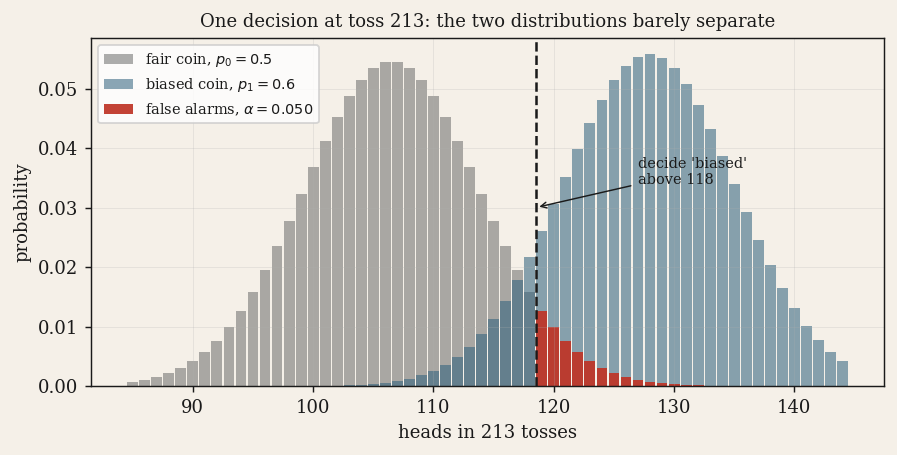

In [4]:
x = np.arange(85, 145)
fig, ax = plt.subplots(figsize=(7.0, 3.6), facecolor=PARCH); ax.set_facecolor(PARCH)
ax.bar(x, binom.pmf(x, n_fixed, p0), width=0.9, color=STONE, alpha=0.55,
       label=rf"fair coin, $p_0={p0}$")
ax.bar(x, binom.pmf(x, n_fixed, p1), width=0.9, color=SEA, alpha=0.55,
       label=rf"biased coin, $p_1={p1}$")
tail0 = x[x > k_crit]
ax.bar(tail0, binom.pmf(tail0, n_fixed, p0), width=0.9, color=SIG, alpha=0.95,
       label=rf"false alarms, $\alpha={alpha_actual:.3f}$")
ax.axvline(k_crit + 0.5, color=INK, lw=1.4, ls="--")
ax.annotate(f"decide 'biased'\nabove {k_crit}", xy=(k_crit + 0.5, 0.030),
            xytext=(k_crit + 9, 0.034), fontsize=8, color=INK,
            arrowprops=dict(arrowstyle="->", color=INK, lw=0.8))
ax.set_xlabel(f"heads in {n_fixed} tosses"); ax.set_ylabel("probability")
ax.set_title(f"One decision at toss {n_fixed}: the two distributions barely separate", fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout(); show(fig)

The two distributions overlap heavily even after 213 tosses. That overlap **is** the problem:
it is why $n$ is four times the information scale rather than equal to it.

> **worked example** — an exact, non-randomised, one-sided binomial test needs **213 tosses**
> to reach power 0.90 at level 0.05 against $p_1=0.6$. That is $4.3/D$: the factor of four over
> the information scale is the price of the two error probabilities you demanded.

## 3. Sequential: a calibrated CUSUM

Now the change happens at an unknown time and you want to notice it *soon*. Accumulate the
log-likelihood ratio and floor it at zero:

$$W_n=\max(0,\;W_{n-1}+\ell(y_n)),\qquad \text{alarm when } W_n\ge h.$$

The floor is what makes it sequential: evidence for "no change" is discarded rather than banked,
so a long quiet stretch cannot mask a change that starts later.

Calibration is by **false-alarm rate**, not by a p-value: we set the mean time between false
alarms, $\mathbb{E}_0[T]$, to match the rate you would incur by repeating the fixed-sample test
forever — one test every $n$ tosses, each firing wrongly with probability $\alpha$.

In [5]:
def cusum(p, h, runs, seed, cap=60_000, keep_paths=0):
    """Vectorised CUSUM stopping times for `runs` independent streams at bias p."""
    rng = np.random.default_rng(seed)
    W = np.zeros(runs); stop = np.full(runs, cap); live = np.ones(runs, bool)
    paths = [] if keep_paths else None
    for step in range(cap):
        y = rng.random(runs) < p
        W = np.maximum(0.0, W + np.where(y, l_head, l_tail))
        if keep_paths and step < 400:
            paths.append(W[:keep_paths].copy())
        hit = live & (W >= h); stop[hit] = step + 1; live &= ~hit
        if not live.any():
            break
    return (stop, np.array(paths)) if keep_paths else stop

target_arl0 = n_fixed / alpha
lo, hi = 1.0, 10.0
for _ in range(10):                                  # bisection on the threshold
    mid = 0.5 * (lo + hi)
    if cusum(p0, mid, 300, SEED).mean() > target_arl0: hi = mid
    else: lo = mid
h = 0.5 * (lo + hi)

arl0  = cusum(p0, h, 600, SEED + 1)
delay = cusum(p1, h, 600, SEED + 2)
print(f"threshold h* = {h:.3f}")
print(f"\nnull run lengths, matched approximately:")
print(f"  repeating the fixed test: n/alpha_actual = {n_fixed/alpha_actual:.0f} tosses per false alarm")
print(f"  CUSUM, measured         : {arl0.mean():.0f} +- {arl0.std()/math.sqrt(len(arl0)):.0f}")

threshold h* = 4.371

null run lengths, matched approximately:
  repeating the fixed test: n/alpha_actual = 4266 tosses per false alarm
  CUSUM, measured         : 4522 +- 166


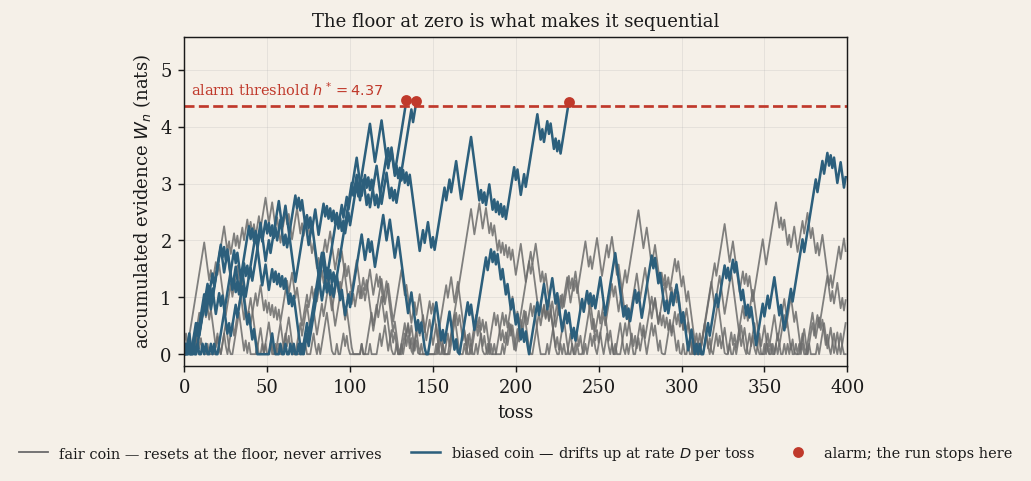

In [6]:
# A CUSUM STOPS at its alarm, so each path is truncated at its first crossing of h.
_, paths  = cusum(p1, h, 600, SEED + 5, keep_paths=4)
_, npaths = cusum(p0, h, 600, SEED + 6, keep_paths=4)

def truncate(col, h):
    hit = np.argmax(col >= h) if (col >= h).any() else len(col)
    return col[:hit + 1] if (col >= h).any() else col

fig, ax = plt.subplots(figsize=(7.4, 3.9), facecolor=PARCH); ax.set_facecolor(PARCH)
for j in range(npaths.shape[1]):
    ax.plot(truncate(npaths[:, j], h), color=STONE, lw=1.0, alpha=0.85)
for j in range(paths.shape[1]):
    seg = truncate(paths[:, j], h)
    ax.plot(seg, color=SEA, lw=1.4)
    if seg[-1] >= h:
        ax.plot(len(seg) - 1, seg[-1], "o", color=SIG, ms=5, zorder=5)
ax.axhline(h, color=SIG, lw=1.5, ls="--")
ax.text(4, h + 0.12, rf"alarm threshold $h^*={h:.2f}$", color=SIG, fontsize=8, va="bottom")
ax.plot([], [], color=STONE, lw=1.0, label="fair coin — resets at the floor, never arrives")
ax.plot([], [], color=SEA, lw=1.4, label="biased coin — drifts up at rate $D$ per toss")
ax.plot([], [], "o", color=SIG, ms=5, label="alarm; the run stops here")
ax.set_xlim(0, 400); ax.set_ylim(-0.2, h + 1.2)
ax.set_xlabel("toss"); ax.set_ylabel(r"accumulated evidence $W_n$ (nats)")
ax.set_title("The floor at zero is what makes it sequential", fontsize=10)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=False)
fig.tight_layout(); show(fig)

Grey paths wander near zero and are repeatedly reset; blue paths drift upward at rate $D$ per
toss until they cross. The reset is why an old quiet stretch costs nothing.

In [7]:
p_by_deadline = (delay <= n_fixed).mean()
print(f"detection delay over {len(delay)} runs:")
print(f"  mean               {delay.mean():8.1f} +- {delay.std()/math.sqrt(len(delay)):.1f} tosses")
print(f"  median             {np.median(delay):8.1f}")
print(f"  90th percentile    {np.percentile(delay, 90):8.1f}")
print(f"  P(alarm by toss {n_fixed}) = {100*p_by_deadline:.1f}%")
print(f"\n  first-order prediction h/D = {h/D:.1f}; measured mean / prediction = {delay.mean()/(h/D):.2f}")
print(f"  martingale bound E0[T] >= e^h = {math.exp(h):.0f}; measured is {arl0.mean()/math.exp(h):.0f}x larger")

detection delay over 600 runs:
  mean                  174.1 +- 4.2 tosses
  median                145.5
  90th percentile       308.3
  P(alarm by toss 213) = 74.8%

  first-order prediction h/D = 217.1; measured mean / prediction = 0.80
  martingale bound E0[T] >= e^h = 79; measured is 57x larger


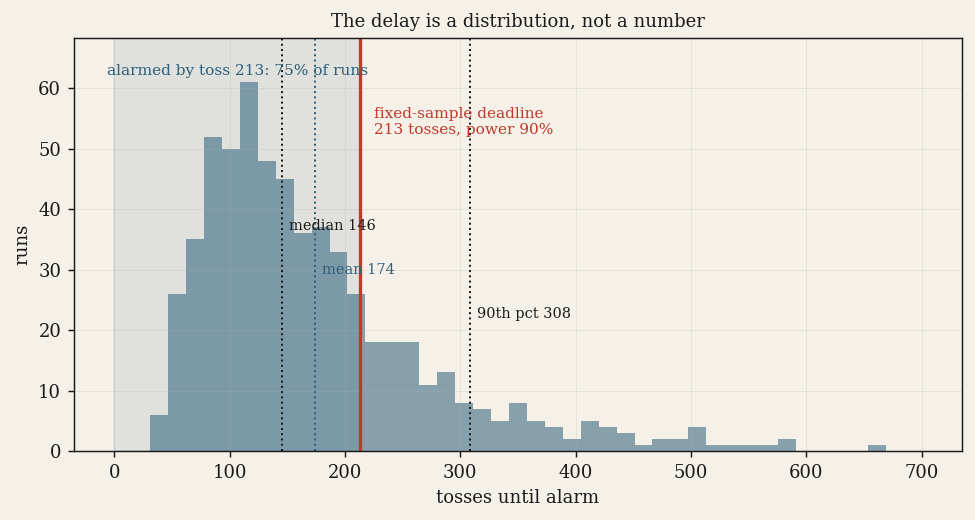

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 4.1), facecolor=PARCH); ax.set_facecolor(PARCH)
counts, edges, _ = ax.hist(delay, bins=45, range=(0, 700), color=SEA, alpha=0.55, edgecolor="none")
top = counts.max()
ax.axvspan(0, n_fixed, color=SEA, alpha=0.10)
ax.text(n_fixed/2, top*1.02, f"alarmed by toss {n_fixed}: {100*p_by_deadline:.0f}% of runs",
        color=SEA, fontsize=8.5, ha="center")
ax.axvline(n_fixed, color=SIG, lw=1.8)
ax.text(n_fixed + 12, top*0.86,
        f"fixed-sample deadline\n{n_fixed} tosses, power {100*power_actual:.0f}%",
        color=SIG, fontsize=8.5)
for value, colour, label, dy in ((np.median(delay), INK, "median", 0.60),
                                 (delay.mean(), SEA, "mean", 0.48),
                                 (np.percentile(delay, 90), INK, "90th pct", 0.36)):
    ax.axvline(value, color=colour, lw=1.1, ls=":")
    ax.text(value + 6, top*dy, f"{label} {value:.0f}", color=colour, fontsize=8)
ax.set_ylim(0, top*1.12)
ax.set_xlabel("tosses until alarm"); ax.set_ylabel("runs")
ax.set_title("The delay is a distribution, not a number", fontsize=10)
fig.tight_layout(); show(fig)

> **worked example** — with the null run lengths matched approximately
> ($n/\alpha \approx 4266$ tosses per false alarm for the repeated fixed test, $4522\pm166$
> measured for the CUSUM), the sequential detector alarms after **174 tosses on average** and
> **145 at the median** — but its 90th percentile is **308**, and by toss 213 it has alarmed in
> only **75 %** of runs, against the fixed test's **90 %** power at exactly that point.
>
> So the CUSUM is *earlier on average* and *later in the tail*. Neither procedure dominates.
> These are different summaries of different questions, and the comparison is only meaningful
> once you say which summary you meant.

This is the sixth choice, the one nobody made explicitly. Even after fixing $p_0$, $p_1$,
$\alpha$, the power, and the false-alarm rate, "how many tosses?" still depends on whether you
want a small **mean** delay, a high **probability of detection by a deadline**, or a bounded
**quantile** of the delay. The three answers here are 174, 213, and 308 — for the same coin, at
the same false-alarm rate.

Two details recur throughout this project, and both are worth separating carefully from the
claims they resemble.

> **worked example** — the mean delay lands at about $0.80\,h/D$, not at $h/D$. The reflecting
> floor shortens first passage.

> **C25 — result** — the project measures the same kind of factor for the quantum detector:
> note 01 §7 reports delays at 0.8–0.9 of $h/I$. That is a separate measurement on a different
> process; the numerical similarity above illustrates it but is not evidence for it.

> **worked example** — the martingale bound $\mathbb{E}_0[T]\ge e^{h}$ holds here but is
> too loose to calibrate with by a factor of about 60 here, which is why the threshold was
> found by simulation.

> **C10 — result** — the project measures that looseness in its own setting and finds a factor
> of $10^2$–$10^4$ for the restarted-SPRT variant under an action-conditional null. Our simpler
> CUSUM is a *different* quantity, not a check of C10.

## 4. Tosses are not seconds

An experiment does not spend tosses, it spends time. If one toss costs $c$ seconds of cycle
time, what matters is information **per second**. This is where the physics starts to bite, and
it is why the project's regime map has a time axis at all.

In [9]:
print(f"{'cycle time':>12} {'fixed sample':>14} {'CUSUM mean':>12} {'CUSUM 90th pct':>16}")
for c in (0.001, 0.05, 1.0):
    print(f"{c:>10} s {n_fixed*c:>12.2f} s {delay.mean()*c:>10.2f} s {np.percentile(delay,90)*c:>14.2f} s")

  cycle time   fixed sample   CUSUM mean   CUSUM 90th pct
     0.001 s         0.21 s       0.17 s           0.31 s
      0.05 s        10.65 s       8.71 s          15.42 s
       1.0 s       213.00 s     174.14 s         308.30 s


## 5. Does the starting probability matter?

Ask "is a change easier to detect near a fair coin, or near a strongly biased one?" and you will
get a confident answer. The answer is **not determined** until you say what is held fixed.

Two natural choices, deliberately matched at $p_0=0.5$ so they are indistinguishable there:

- a fixed **absolute** change, $p_1=p_0+\Delta p$;
- a fixed change in **log-odds**, $\operatorname{logit}p_1=\operatorname{logit}p_0+\delta$.

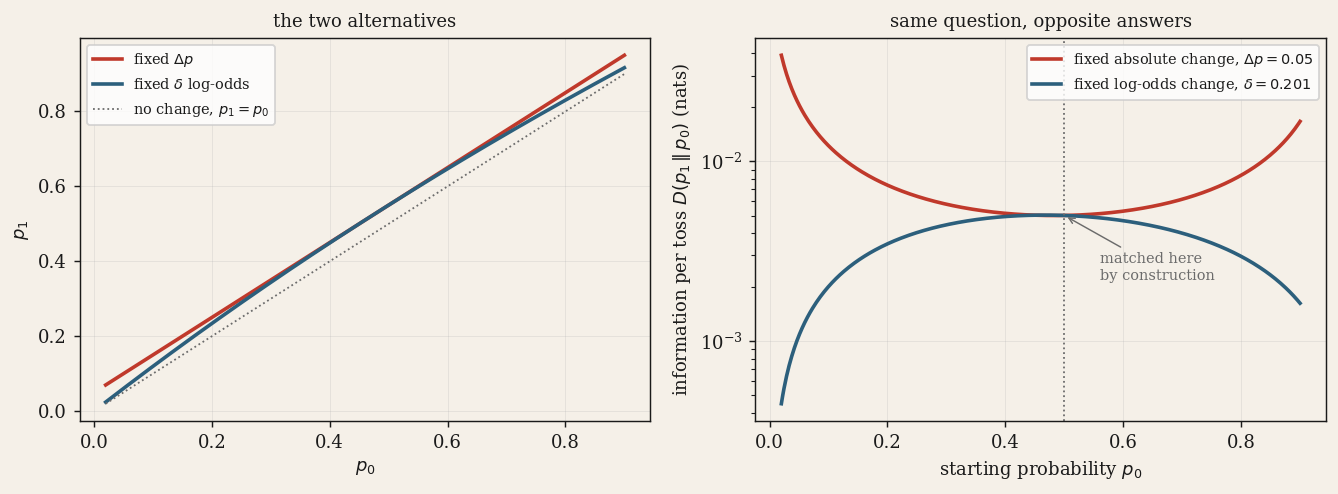

at p0 = 0.05: fixed dp gives 0.02065, fixed log-odds gives 0.00108  ->  19x apart
at p0 = 0.02: fixed dp gives 0.03899, fixed log-odds gives 0.00045  ->  87x apart
fixed dp       is maximised at p0 = 0.02, minimised at 0.48
fixed log-odds is maximised at p0 = 0.47, minimised at 0.02


In [10]:
logit = lambda p: math.log(p/(1-p))
expit = lambda z: 1.0/(1.0 + math.exp(-z))

dp = 0.05
delta = logit(0.5 + dp) - logit(0.5)          # matched to dp at p0 = 0.5
grid = np.linspace(0.02, 0.90, 400)
D_abs  = np.array([DB(p + dp, p) for p in grid])
D_odds = np.array([DB(expit(logit(p) + delta), p) for p in grid])

fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.9), facecolor=PARCH)
ax = axes[0]; ax.set_facecolor(PARCH)
ax.plot(grid, [p + dp for p in grid], color=SIG, lw=2, label=r"fixed $\Delta p$")
ax.plot(grid, [expit(logit(p) + delta) for p in grid], color=SEA, lw=2, label=r"fixed $\delta$ log-odds")
ax.plot(grid, grid, color=STONE, lw=1, ls=":", label=r"no change, $p_1=p_0$")
ax.set_xlabel(r"$p_0$"); ax.set_ylabel(r"$p_1$"); ax.legend(fontsize=8)
ax.set_title("the two alternatives", fontsize=10)

ax = axes[1]; ax.set_facecolor(PARCH)
ax.plot(grid, D_abs,  color=SIG, lw=2, label=rf"fixed absolute change, $\Delta p={dp}$")
ax.plot(grid, D_odds, color=SEA, lw=2, label=rf"fixed log-odds change, $\delta={delta:.3f}$")
ax.axvline(0.5, color=STONE, lw=1, ls=":")
ax.annotate("matched here\nby construction", xy=(0.5, D_abs[np.argmin(abs(grid-0.5))]),
            xytext=(0.56, 0.0022), fontsize=8, color=STONE,
            arrowprops=dict(arrowstyle="->", color=STONE, lw=0.8))
ax.set_yscale("log"); ax.set_xlabel(r"starting probability $p_0$")
ax.set_ylabel(r"information per toss $D(p_1\,\|\,p_0)$ (nats)")
ax.set_title("same question, opposite answers", fontsize=10); ax.legend(fontsize=8)
fig.tight_layout(); show(fig)

for probe in (0.05, 0.02):
    a = DB(probe + dp, probe); b = DB(expit(logit(probe) + delta), probe)
    print(f"at p0 = {probe:.2f}: fixed dp gives {a:.5f}, fixed log-odds gives {b:.5f}  ->  {a/b:.0f}x apart")
print(f"fixed dp       is maximised at p0 = {grid[D_abs.argmax()]:.2f}, minimised at {grid[D_abs.argmin()]:.2f}")
print(f"fixed log-odds is maximised at p0 = {grid[D_odds.argmax()]:.2f}, minimised at {grid[D_odds.argmin()]:.2f}")

> **worked example** — the two curves run in **opposite directions**. Under a fixed absolute
> change, information is *lowest* near a fair coin and rises sharply toward the edges. Under a
> fixed log-odds change, it is *highest* near a fair coin and collapses at the edges. At
> $p_0=0.05$ they differ by about **19×**, at $p_0=0.02$ by about **87×**, and they agree only
> at $p_0=0.5$, where they were matched on purpose.
>
> "Does the starting probability matter?" is therefore not a question about coins. It is a
> question about which alternative you meant, and the answer flips with it. Any advice of the
> form *"operate near the edge"* or *"operate near the middle"* is empty until the held-fixed
> quantity is named.

In notebook 02 the two operating points of the quantum sensor sit at opposite ends of exactly
this axis: the dark extremum works at small $p_0$, mid-fringe at $p_0=1/2$. Which one wins
depends on what the physics holds fixed, and the answer is not the same in every regime.

> **C05 — result** — that regime dependence is the crossover this project maps: the crossover in
> $\tau_c/c$ is amplitude-dependent beyond leading order, and absent altogether at high contrast.

## What this notebook established

| conclusion | kind |
|---|---|
| $D(p_1\|p_0)=0.0201$ nats/toss; the problem's scale is $1/D\approx 50$ tosses | worked example |
| Exact fixed-sample test: 213 tosses, power 0.9028 at level 0.0499 | worked example |
| CUSUM at a matched false-alarm rate: mean 174, median 145, 90th pct 308, and 75 % detected by toss 213 | worked example |
| Neither procedure dominates; "how many tosses?" needs a chosen summary | worked example |
| Mean delay $\approx 0.80\,h/D$ for this coin | worked example |
| Delays at 0.8–0.9 of $h/I$ for the quantum detector | [`C25`](../ledgers/status.yaml) — result |
| $\mathbb{E}_0[T]\ge e^h$ is far too loose to calibrate with, in this project's setting | [`C10`](../ledgers/status.yaml) — result |
| Fixed $\Delta p$ and fixed $\Delta$log-odds answer "does $p_0$ matter?" oppositely | worked example |
| The operating-point crossover is amplitude-dependent | [`C05`](../ledgers/status.yaml) — result |

The worked examples are illustrations computed here. The three claim rows are established
elsewhere in this repository, reproduced under its certified environment, and are cited — not
re-derived — above.

---

## The question this leaves open

Every calculation above assumed each toss is **independent**. The CUSUM sums log-likelihood
ratios as if no toss knows anything about the last one.

Real hidden biases drift. If the coin's probability wanders slowly, two streams can show *the
same average number of heads* and still be told apart — because one of them remembers.

### What changes when the coin's probability has a memory of previous tosses?

That is notebook 01, and it is where Signals in Darkness actually begins.